In [18]:
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

In [2]:
import pandas as pd
df=pd.read_csv("assignment-data.csv")
df.head(6)  #check if dataset is loaded

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [3]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [4]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

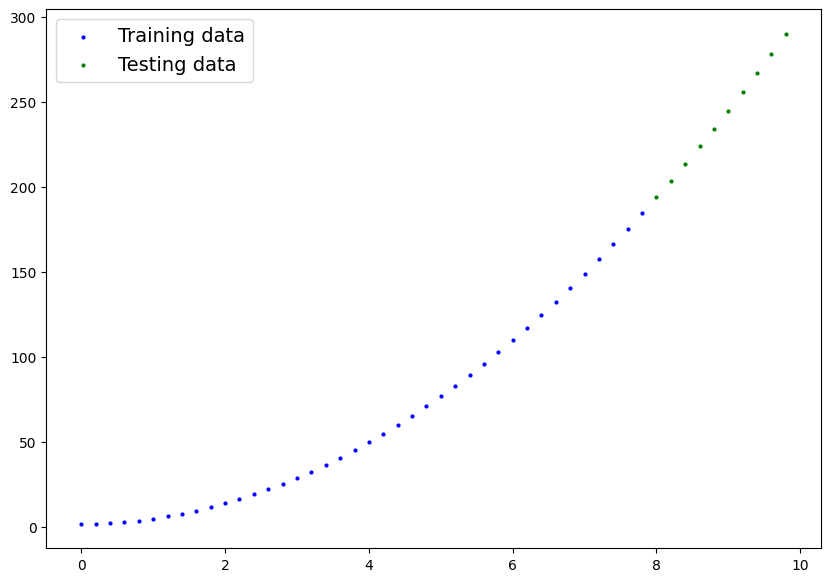

In [ ]:
plot_predictions(X_train, y_train, X_test, y_test)

In [7]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [8]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [9]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579]])

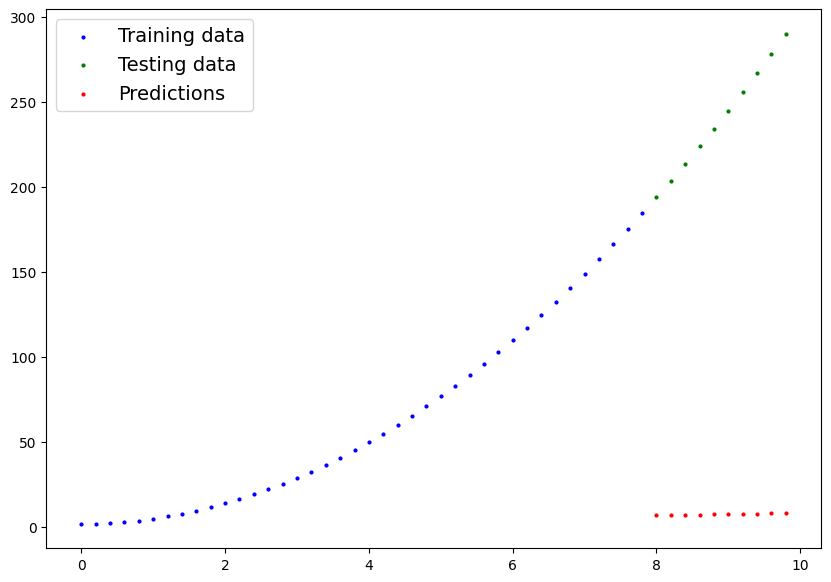

In [10]:
plot_predictions(predictions=y_preds)

In [11]:
# Loss Function and Optimizer

loss_fn = nn.L1Loss()      # MAE

optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.01
)

In [15]:
# Training

torch.manual_seed(42)

epochs = 600

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:

        epoch_count.append(epoch)
        train_loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Train Loss: 32.9293 | Test Loss: 167.5564
Epoch: 10 | Train Loss: 32.0263 | Test Loss: 164.8653
Epoch: 20 | Train Loss: 31.1832 | Test Loss: 162.2779
Epoch: 30 | Train Loss: 30.3648 | Test Loss: 159.7165
Epoch: 40 | Train Loss: 29.5999 | Test Loss: 157.2519
Epoch: 50 | Train Loss: 28.8669 | Test Loss: 154.8289
Epoch: 60 | Train Loss: 28.1709 | Test Loss: 152.4795
Epoch: 70 | Train Loss: 27.5235 | Test Loss: 150.2039
Epoch: 80 | Train Loss: 26.8856 | Test Loss: 147.9596
Epoch: 90 | Train Loss: 26.3229 | Test Loss: 145.8403
Epoch: 100 | Train Loss: 25.7602 | Test Loss: 143.7210
Epoch: 110 | Train Loss: 25.2431 | Test Loss: 141.7008
Epoch: 120 | Train Loss: 24.7632 | Test Loss: 139.7467
Epoch: 130 | Train Loss: 24.2834 | Test Loss: 137.7926
Epoch: 140 | Train Loss: 23.8697 | Test Loss: 135.9952
Epoch: 150 | Train Loss: 23.4697 | Test Loss: 134.2151
Epoch: 160 | Train Loss: 23.0697 | Test Loss: 132.4351
Epoch: 170 | Train Loss: 22.7317 | Test Loss: 130.8198
Epoch: 180 | Train Lo

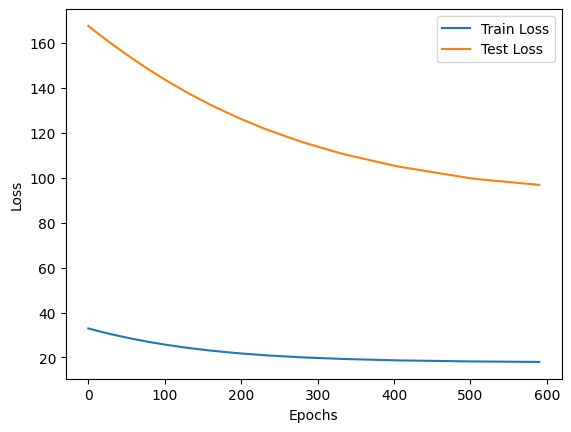

In [16]:
# Loss Curve

plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

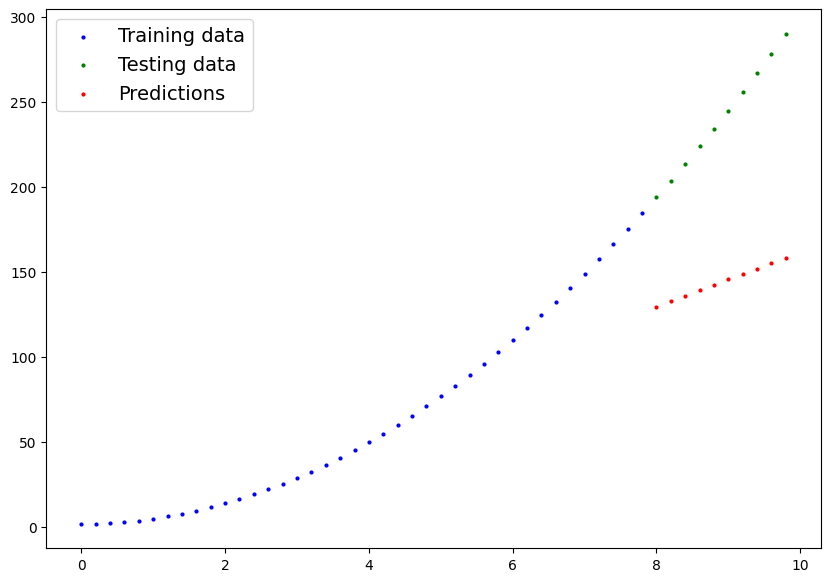

In [17]:
# Evaluation

model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(
    predictions=y_preds
)

# Dataset - data2

In [19]:
import pandas as pd
df=pd.read_csv("assignment-data2.csv")
df.head(6)  #check if dataset is loaded

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [20]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


In [21]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

In [22]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

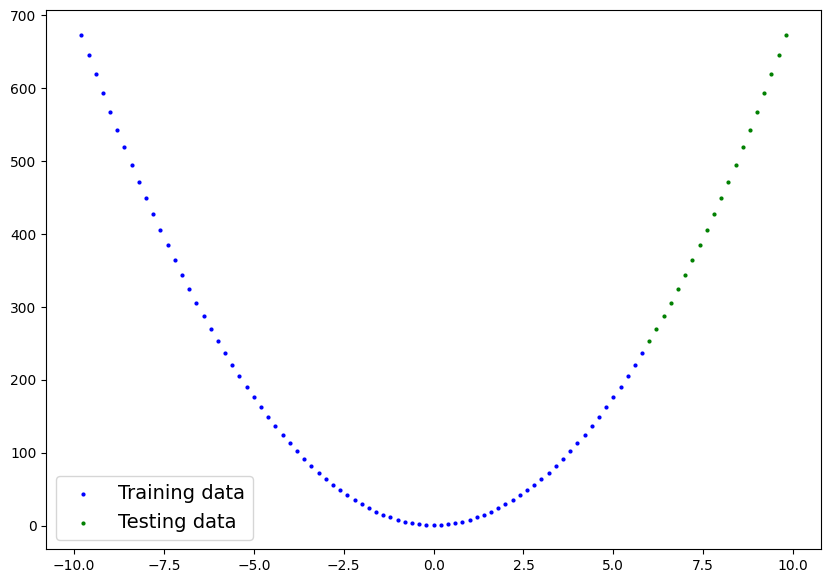

In [23]:
plot_predictions(X_train, y_train, X_test, y_test)

In [24]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [25]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created

list(model_0.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [26]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289]])

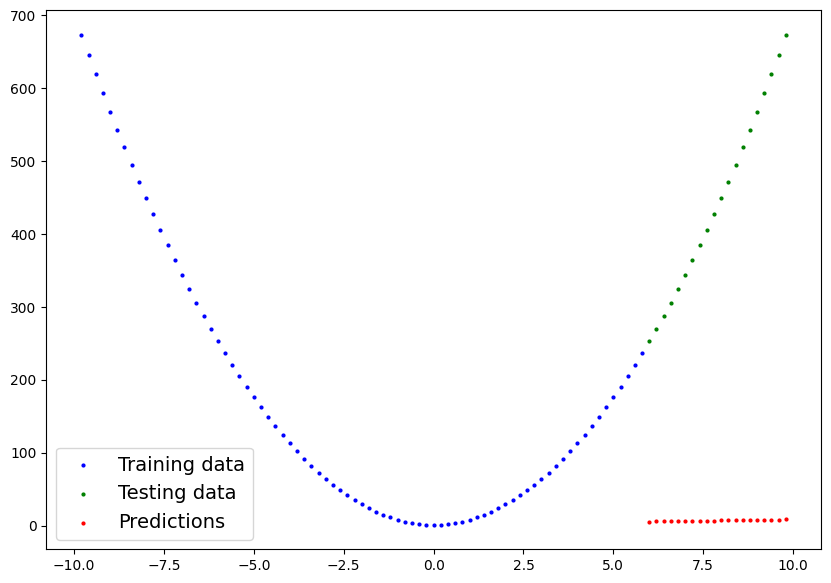

In [27]:
plot_predictions(predictions=y_preds)


In [28]:
# Loss Function and Optimizer

loss_fn = nn.L1Loss()      # MAE

optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.01
)

In [29]:
# Training

torch.manual_seed(42)

epochs = 600

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:

        epoch_count.append(epoch)
        train_loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Train Loss: 175.2991 | Test Loss: 440.4581
Epoch: 10 | Train Loss: 174.7991 | Test Loss: 441.9381
Epoch: 20 | Train Loss: 174.3006 | Test Loss: 443.4191
Epoch: 30 | Train Loss: 173.8056 | Test Loss: 444.9017
Epoch: 40 | Train Loss: 173.3106 | Test Loss: 446.3842
Epoch: 50 | Train Loss: 172.8199 | Test Loss: 447.8657
Epoch: 60 | Train Loss: 172.3340 | Test Loss: 449.3527
Epoch: 70 | Train Loss: 171.8487 | Test Loss: 450.8402
Epoch: 80 | Train Loss: 171.3633 | Test Loss: 452.3278
Epoch: 90 | Train Loss: 170.8779 | Test Loss: 453.8154
Epoch: 100 | Train Loss: 170.4003 | Test Loss: 455.2975
Epoch: 110 | Train Loss: 169.9236 | Test Loss: 456.7797
Epoch: 120 | Train Loss: 169.4469 | Test Loss: 458.2618
Epoch: 130 | Train Loss: 168.9701 | Test Loss: 459.7440
Epoch: 140 | Train Loss: 168.4934 | Test Loss: 461.2261
Epoch: 150 | Train Loss: 168.0189 | Test Loss: 462.7054
Epoch: 160 | Train Loss: 167.5527 | Test Loss: 464.1780
Epoch: 170 | Train Loss: 167.0865 | Test Loss: 465.6507
Epo

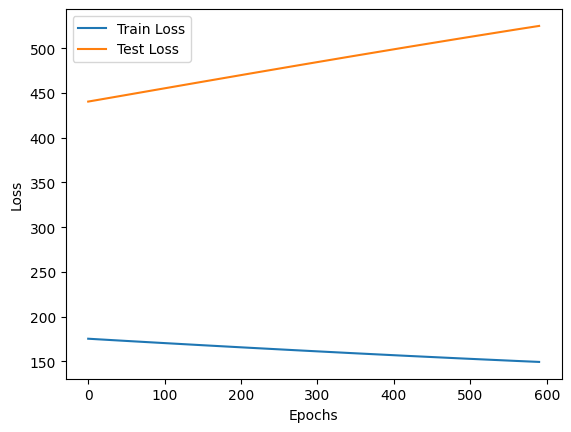

In [30]:
# Loss Curve

plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

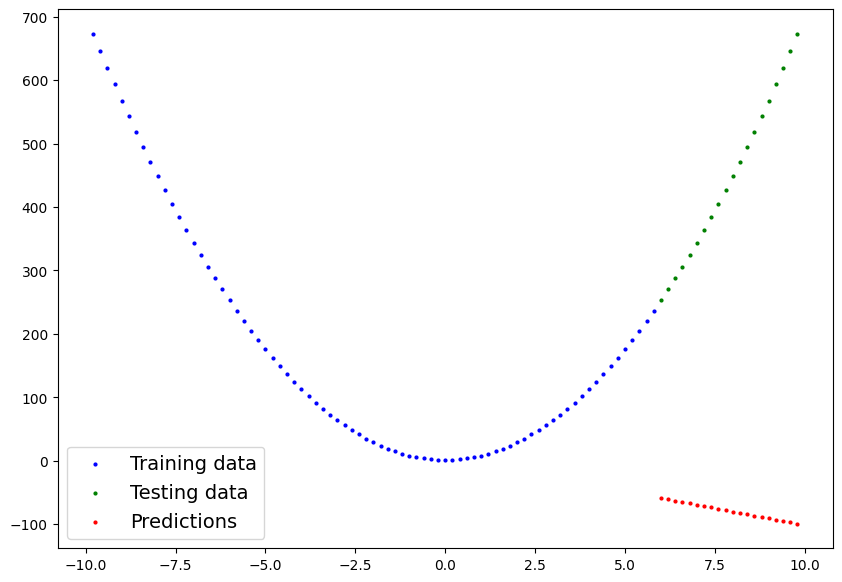

In [31]:
# Evaluation

model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(
    predictions=y_preds
)

# Dataset- linear regression

In [32]:
import pandas as pd
df=pd.read_csv("linear-regression-data1.csv")
df.head(6)  #check if dataset is loaded

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


In [33]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [34]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [35]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

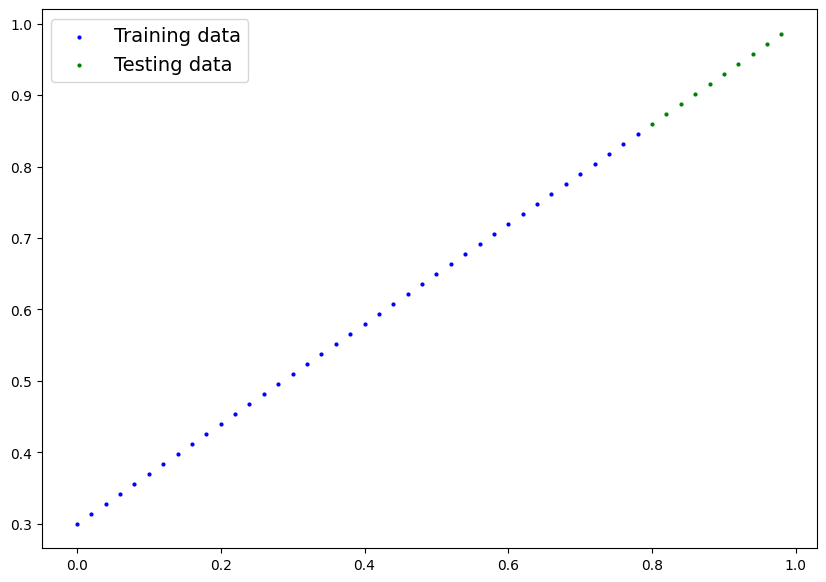

In [36]:
plot_predictions(X_train, y_train, X_test, y_test)

In [37]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [38]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created

list(model_0.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [39]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028]])

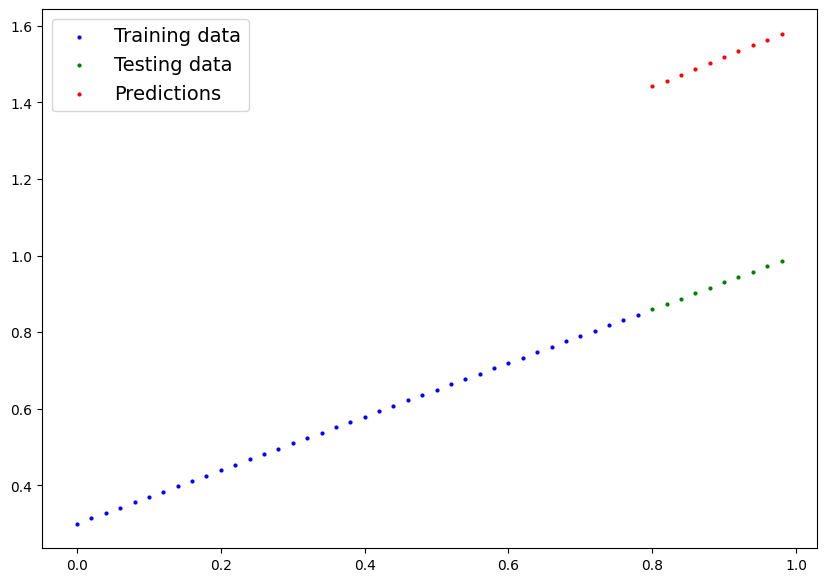

In [40]:
plot_predictions(predictions=y_preds)


In [41]:
# Loss Function and Optimizer

loss_fn = nn.L1Loss()      # MAE

optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.01
)

In [42]:
# Training

torch.manual_seed(42)

epochs = 600

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:

        epoch_count.append(epoch)
        train_loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Train Loss: 0.5552 | Test Loss: 0.5740
Epoch: 10 | Train Loss: 0.4400 | Test Loss: 0.4393
Epoch: 20 | Train Loss: 0.3248 | Test Loss: 0.3046
Epoch: 30 | Train Loss: 0.2095 | Test Loss: 0.1698
Epoch: 40 | Train Loss: 0.0943 | Test Loss: 0.0351
Epoch: 50 | Train Loss: 0.0239 | Test Loss: 0.0478
Epoch: 60 | Train Loss: 0.0200 | Test Loss: 0.0458
Epoch: 70 | Train Loss: 0.0165 | Test Loss: 0.0375
Epoch: 80 | Train Loss: 0.0131 | Test Loss: 0.0299
Epoch: 90 | Train Loss: 0.0097 | Test Loss: 0.0217
Epoch: 100 | Train Loss: 0.0062 | Test Loss: 0.0141
Epoch: 110 | Train Loss: 0.0028 | Test Loss: 0.0058
Epoch: 120 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 130 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 140 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 150 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 160 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 170 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 180 | Train Loss: 0.0013 | Test Loss: 0.0138
Epoch: 190 | Train Loss

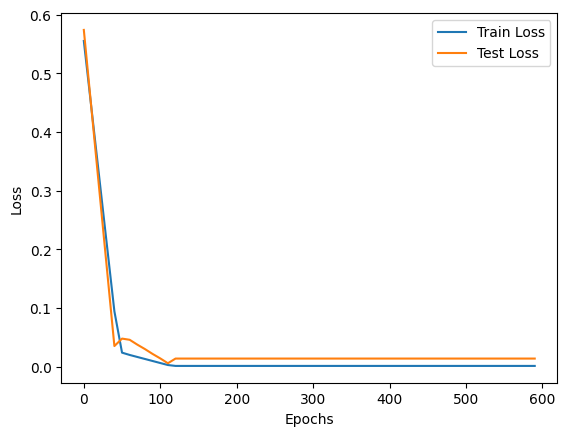

In [43]:
# Loss Curve

plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

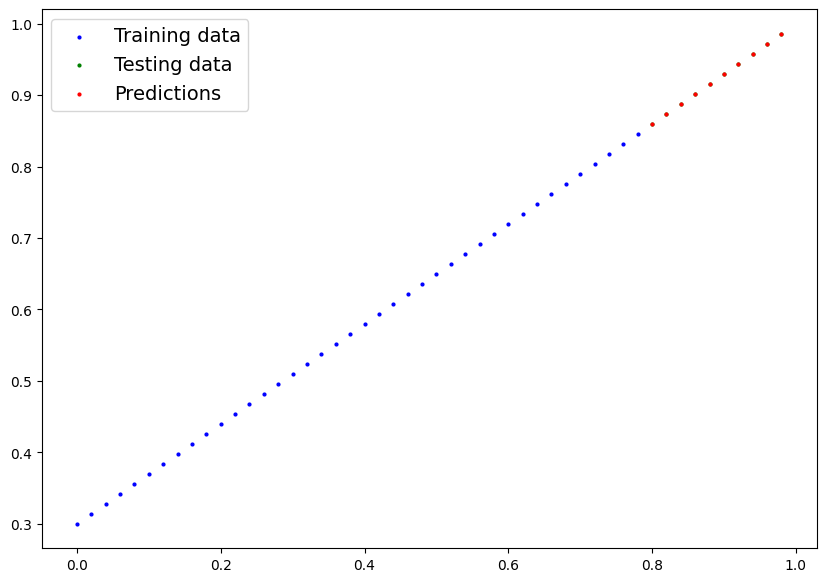

In [44]:
# Evaluation

model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(
    predictions=y_preds
)

# Discussion


This assignment required us to develop a neural network for linear regression in PyTorch. First, the dataset was loaded as tensors and split into a training set and a testing set. A single layer of neurons was used to predict the output variable depending on the input variable. In training, we observed a gradual reduction of the Mean Absolute Error (MAE) loss, which means the pattern in the data was learned. Prediction graphs showed a good fit of the regression line to the actual data points. The loss graph indicated stability during convergence with no large fluctuations, implying efficient SGD parameter optimization.

# Conclusion

A basic neural network consisting of only one linear layer has successfully managed to learn the linear relationship from the given dataset. The reduction in the loss function values during both training and testing and also correct plots for predictions show that the model has been generalized well to unseen data.